C:\Users\asusa\AppData\Local\Temp\ipykernel_23452\3907308399.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


   open_time      open      high       low     close    volume  \
0 2017-08-17  0.010427  0.011371  0.013499  0.010646  0.000746   
1 2017-08-18  0.010656  0.010300  0.010944  0.008930  0.001278   
2 2017-08-19  0.008939  0.008543  0.010078  0.009237  0.000201   
3 2017-08-20  0.009062  0.008791  0.011859  0.008715  0.000314   
4 2017-08-21  0.008558  0.007931  0.010680  0.008032  0.000610   

               close_time  quote_asset_volume  number_of_trades  \
0 2017-08-17 23:59:59.999            0.000142          0.000084   
1 2017-08-18 23:59:59.999            0.000235          0.000202   
2 2017-08-19 23:59:59.999            0.000033          0.000000   
3 2017-08-20 23:59:59.999            0.000055          0.000011   
4 2017-08-21 23:59:59.999            0.000104          0.000120   

   taker_buy_base_volume  taker_buy_quote_volume  
0               0.001495                0.000277  
1               0.002446                0.000443  
2               0.000582                0.00010

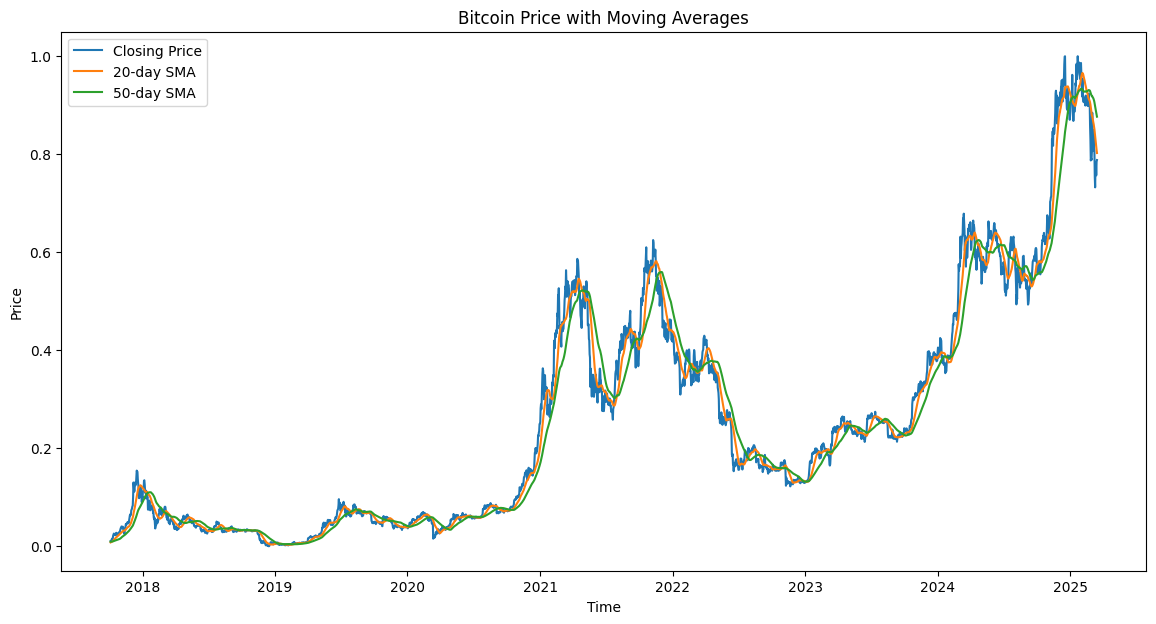

    open_time      open      high       low     close    volume  \
49 2017-10-05  0.009913  0.010145  0.012614  0.010717  0.000725   
50 2017-10-06  0.010985  0.010728  0.014390  0.011461  0.000366   
51 2017-10-07  0.011471  0.011316  0.014590  0.011986  0.000091   
52 2017-10-08  0.012015  0.012995  0.015687  0.014093  0.000382   
53 2017-10-09  0.014103  0.015177  0.016907  0.015521  0.000550   

                close_time  quote_asset_volume  number_of_trades  \
49 2017-10-05 23:59:59.999            0.000133          0.000460   
50 2017-10-06 23:59:59.999            0.000071          0.000289   
51 2017-10-07 23:59:59.999            0.000019          0.000174   
52 2017-10-08 23:59:59.999            0.000078          0.000357   
53 2017-10-09 23:59:59.999            0.000118          0.000540   

    taker_buy_base_volume  taker_buy_quote_volume    SMA_20    SMA_50  \
49               0.000787                0.000141  0.007974  0.009423   
50               0.000454                0

ValueError: cannot reshape array of size 13595 into shape (2719,1,1)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np
from datetime import datetime, timedelta

# Load the data
df = pd.read_csv("bitcoin_prices_2025.csv")

# Convert 'open_time' and 'close_time' to datetime objects
df['open_time'] = pd.to_datetime(df['open_time'])
df['close_time'] = pd.to_datetime(df['close_time'])

# Handle missing values (if any)
df.fillna(method='ffill', inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
df[['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume']] = scaler.fit_transform(df[['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume']])

# Display the first few rows of the preprocessed data
print(df.head())

# Save the preprocessed data to a new CSV file
df.to_csv("bitcoin_prices_preprocessed.csv", index=False)

# Feature Engineering
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['Lag_1'] = df['close'].shift(1)
df['Lag_2'] = df['close'].shift(2)

# Drop rows with NaN values resulting from feature engineering
df.dropna(inplace=True)

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], df['close'], label='Closing Price')
plt.plot(df['open_time'], df['SMA_20'], label='20-day SMA')
plt.plot(df['open_time'], df['SMA_50'], label='50-day SMA')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Bitcoin Price with Moving Averages')
plt.legend()
plt.show()

# Display the first few rows of the data with new features
print(df.head())

# Prepare data for LSTM
X = df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Reshape data for LSTM input (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Build LSTM model with Input layer
model = Sequential()
model.add(Input(shape=(1, 5)))  # Explicitly set time_steps=1, features=5
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model on the entire dataset
model.fit(X, y, epochs=10, batch_size=32, verbose=0)

# Function to generate future dates
def generate_future_dates(start_date, periods):
    date_list = [start_date + timedelta(days=x) for x in range(periods)]
    return date_list

# Make predictions for the next 4 months (approx. 120 days)
future_periods = 120
last_date = df['open_time'].iloc[-1]
future_dates = generate_future_dates(last_date, future_periods)

# Create dummy data for future predictions
future_predictions = []
last_known_close = df['close'].iloc[-1]

for _ in range(future_periods):
    # Create a temporary DataFrame for the future data point
    temp_df = pd.DataFrame({
        'close': [last_known_close],
        'SMA_20': [np.nan],
        'SMA_50': [np.nan],
        'Lag_1': [np.nan],
        'Lag_2': [np.nan]
    })

    # Calculate SMA and lagged values
    temp_df['SMA_20'] = temp_df['close'].rolling(window=20).mean()
    temp_df['SMA_50'] = temp_df['close'].rolling(window=50).mean()
    temp_df['Lag_1'] = last_known_close
    temp_df['Lag_2'] = last_known_close  # Using last_known_close for simplicity

    # Fill NaN values
    temp_df.fillna(method='bfill', inplace=True)

    # Prepare the input for prediction
    future_data = temp_df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
    future_data = future_data.reshape((1, 1, 5))

    # Make prediction
    prediction = model.predict(future_data, verbose=0)[0][0]
    future_predictions.append(prediction)

    # Update last_known_close with the predicted value
    last_known_close = prediction

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], df['close'], label='Historical Price')
plt.plot(future_dates, future_predictions, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Bitcoin Price Prediction for the Next 4 Months')
plt.legend()
plt.show()

   open_time      open      high       low     close    volume  \
0 2017-08-17  0.010427  0.011371  0.013499  0.010646  0.000746   
1 2017-08-18  0.010656  0.010300  0.010944  0.008930  0.001278   
2 2017-08-19  0.008939  0.008543  0.010078  0.009237  0.000201   
3 2017-08-20  0.009062  0.008791  0.011859  0.008715  0.000314   
4 2017-08-21  0.008558  0.007931  0.010680  0.008032  0.000610   

               close_time  quote_asset_volume  number_of_trades  \
0 2017-08-17 23:59:59.999            0.000142          0.000084   
1 2017-08-18 23:59:59.999            0.000235          0.000202   
2 2017-08-19 23:59:59.999            0.000033          0.000000   
3 2017-08-20 23:59:59.999            0.000055          0.000011   
4 2017-08-21 23:59:59.999            0.000104          0.000120   

   taker_buy_base_volume  taker_buy_quote_volume  
0               0.001495                0.000277  
1               0.002446                0.000443  
2               0.000582                0.00010

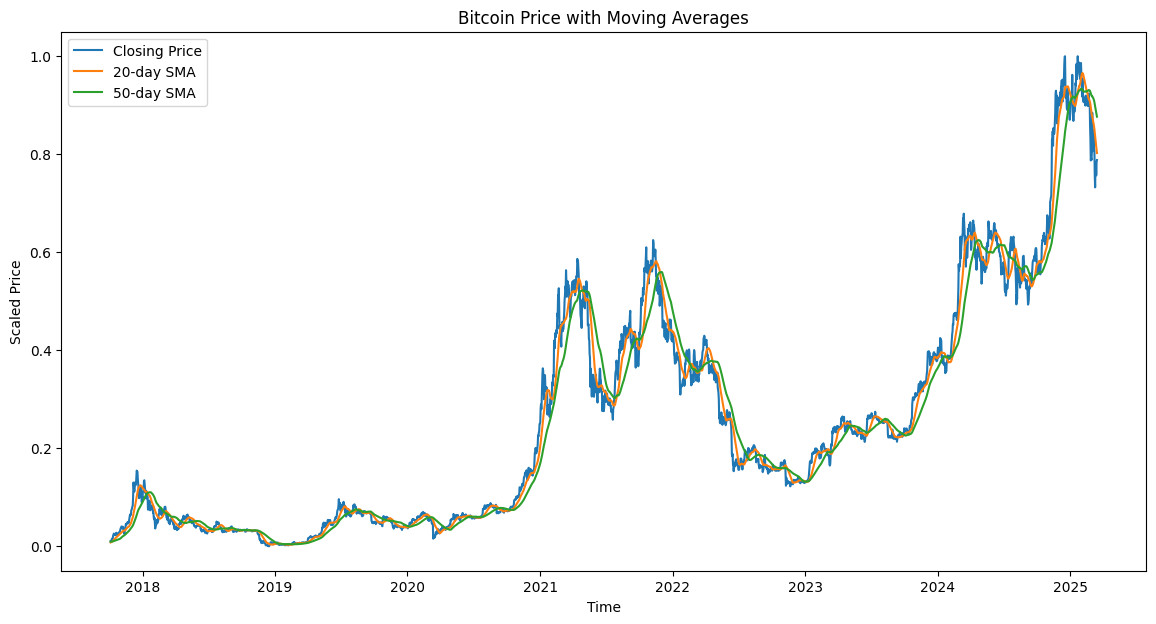

    open_time      open      high       low     close    volume  \
49 2017-10-05  0.009913  0.010145  0.012614  0.010717  0.000725   
50 2017-10-06  0.010985  0.010728  0.014390  0.011461  0.000366   
51 2017-10-07  0.011471  0.011316  0.014590  0.011986  0.000091   
52 2017-10-08  0.012015  0.012995  0.015687  0.014093  0.000382   
53 2017-10-09  0.014103  0.015177  0.016907  0.015521  0.000550   

                close_time  quote_asset_volume  number_of_trades  \
49 2017-10-05 23:59:59.999            0.000133          0.000460   
50 2017-10-06 23:59:59.999            0.000071          0.000289   
51 2017-10-07 23:59:59.999            0.000019          0.000174   
52 2017-10-08 23:59:59.999            0.000078          0.000357   
53 2017-10-09 23:59:59.999            0.000118          0.000540   

    taker_buy_base_volume  taker_buy_quote_volume    SMA_20    SMA_50  \
49               0.000787                0.000141  0.007974  0.009423   
50               0.000454                0

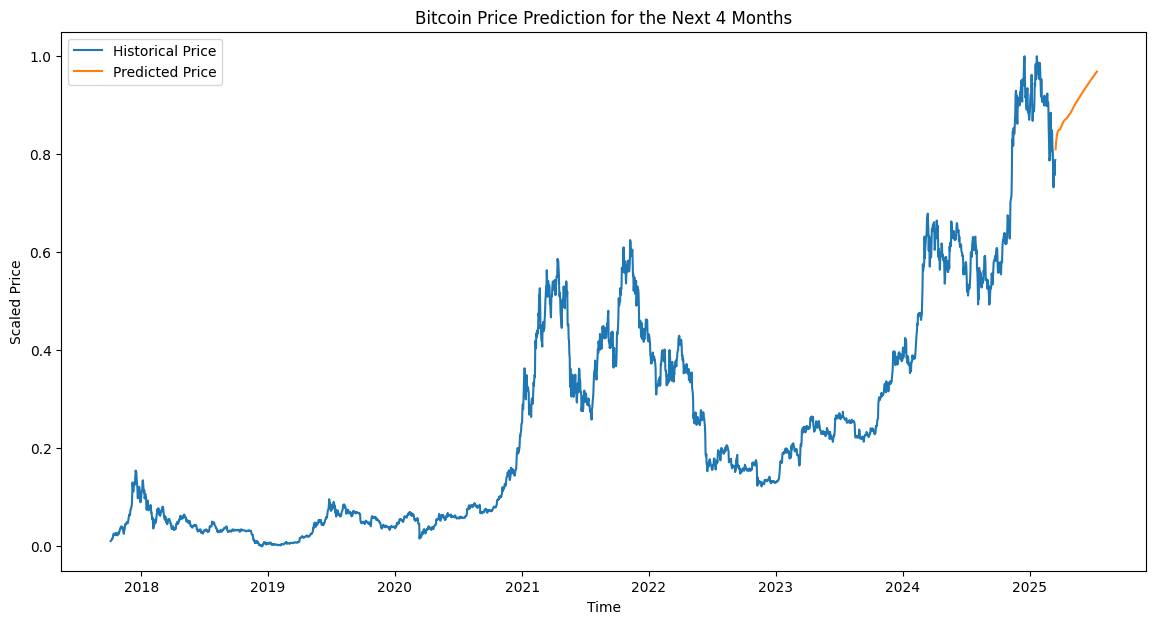

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("bitcoin_prices_2025.csv")

# Convert 'open_time' and 'close_time' to datetime objects
df['open_time'] = pd.to_datetime(df['open_time'])
df['close_time'] = pd.to_datetime(df['close_time'])

# Handle missing values (if any) using forward fill
df.ffill(inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
columns_to_scale = ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Display the first few rows of the preprocessed data
print(df.head())

# Save the preprocessed data to a new CSV file
df.to_csv("bitcoin_prices_preprocessed.csv", index=False)

# Feature Engineering
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['Lag_1'] = df['close'].shift(1)
df['Lag_2'] = df['close'].shift(2)

# Drop rows with NaN values resulting from feature engineering
df.dropna(inplace=True)

# Plotting historical data with moving averages
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], df['close'], label='Closing Price')
plt.plot(df['open_time'], df['SMA_20'], label='20-day SMA')
plt.plot(df['open_time'], df['SMA_50'], label='50-day SMA')
plt.xlabel('Time')
plt.ylabel('Scaled Price')
plt.title('Bitcoin Price with Moving Averages')
plt.legend()
plt.show()

# Display the first few rows of the data with new features
print(df.head())

# Prepare data for LSTM
X = df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
y = df['close'].values

# Reshape data for LSTM input (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Build LSTM model with explicit Input layer
model = Sequential()
model.add(Input(shape=(1, 5)))  # time_steps=1, features=5
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model on the entire dataset
model.fit(X, y, epochs=10, batch_size=32, verbose=0)

# Function to generate future dates
def generate_future_dates(start_date, periods):
    date_list = [start_date + timedelta(days=x) for x in range(1, periods + 1)]
    return date_list

# Make predictions for the next 4 months (approx. 120 days)
future_periods = 120
last_date = df['open_time'].iloc[-1]
future_dates = generate_future_dates(last_date, future_periods)

# Initialize future predictions
future_predictions = []
last_known_close = df['close'].iloc[-1]

# Create a temporary DataFrame to maintain rolling window for SMA calculations
temp_df = df.tail(50).copy()  # Keep last 50 rows for SMA_50 calculation

for _ in range(future_periods):
    # Prepare input data for prediction
    sma_20 = temp_df['close'].tail(20).mean()
    sma_50 = temp_df['close'].tail(50).mean()
    lag_1 = temp_df['close'].iloc[-1]
    lag_2 = temp_df['close'].iloc[-2] if len(temp_df) >= 2 else lag_1
    
    # Create input array
    input_data = np.array([[last_known_close, sma_20, sma_50, lag_1, lag_2]])
    input_data = input_data.reshape((1, 1, 5))
    
    # Make prediction
    prediction = model.predict(input_data, verbose=0)[0][0]
    future_predictions.append(prediction)
    
    # Update temp_df with the predicted close value
    new_row = pd.DataFrame({
        'open_time': [future_dates[_]],
        'close': [prediction],
        'SMA_20': [np.nan],  # Will be recalculated
        'SMA_50': [np.nan],  # Will be recalculated
        'Lag_1': [last_known_close],
        'Lag_2': [lag_1]
    })
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)
    temp_df['SMA_20'] = temp_df['close'].rolling(window=20).mean()
    temp_df['SMA_50'] = temp_df['close'].rolling(window=50).mean()
    temp_df.ffill(inplace=True)  # Forward fill for any remaining NaNs
    
    # Update last_known_close for the next iteration
    last_known_close = prediction

# Plotting historical and predicted prices
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], df['close'], label='Historical Price')
plt.plot(future_dates, future_predictions, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Scaled Price')
plt.title('Bitcoin Price Prediction for the Next 4 Months')
plt.legend()
plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Evaluation Metrics on Test Set:
Mean Squared Error (MSE): 6937368.30
Root Mean Squared Error (RMSE): 2633.89
Mean Absolute Error (MAE): 1954.19
Future predictions saved to 'bitcoin_price_predictions_2025.csv'


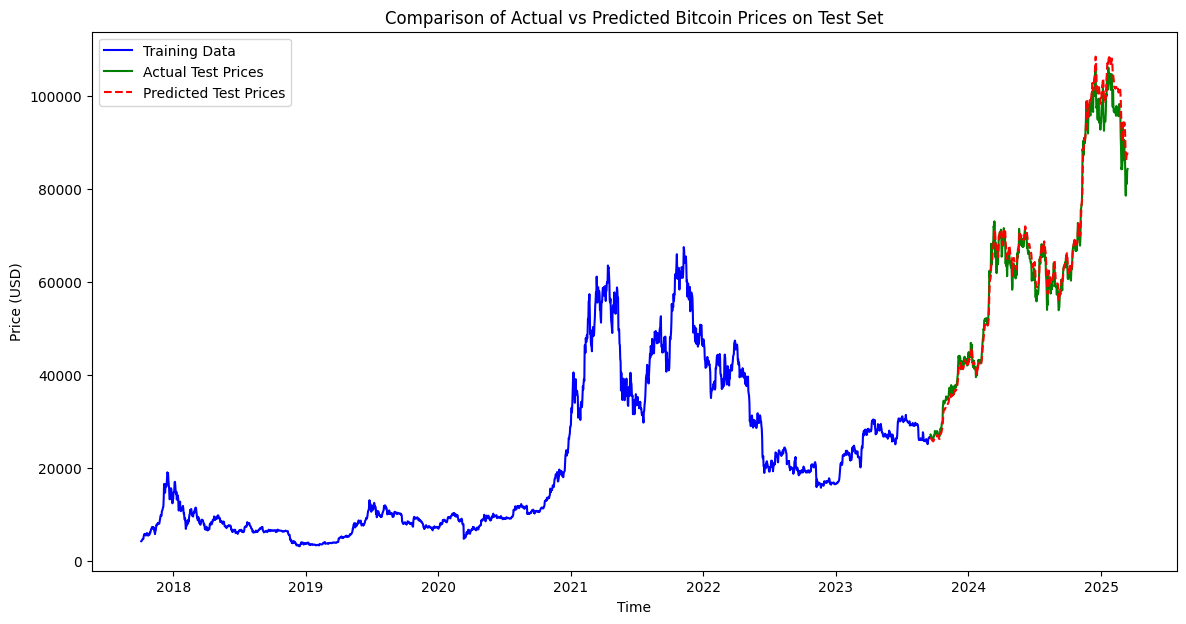

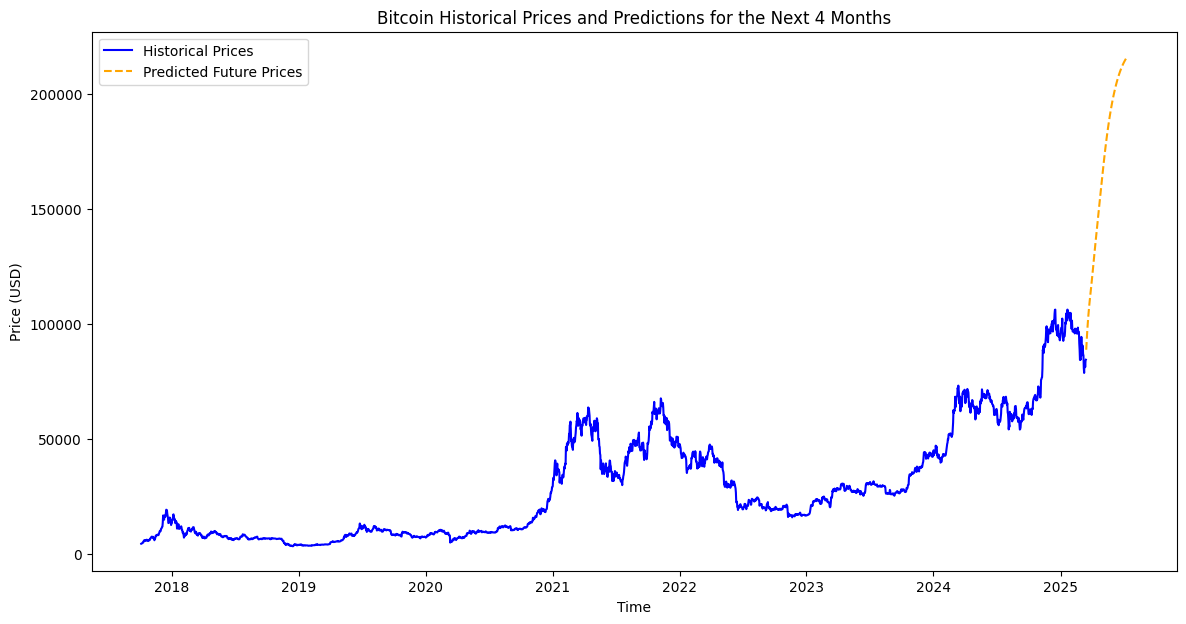

: 

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the data
df = pd.read_csv("bitcoin_prices_2025.csv")

# Convert 'open_time' to datetime
df['open_time'] = pd.to_datetime(df['open_time'])

# Keep a copy of original 'close'
df['close_original'] = df['close']

# Handle missing values using forward fill
df.ffill(inplace=True)

# Scale only 'close'
close_scaler = MinMaxScaler()
df['close'] = close_scaler.fit_transform(df[['close']])

# Feature Engineering on scaled 'close'
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['Lag_1'] = df['close'].shift(1)
df['Lag_2'] = df['close'].shift(2)

# Drop rows with NaN values from feature engineering
df.dropna(inplace=True)

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_df = df[:train_size]
test_df = df[train_size:]

# Prepare training data
X_train = train_df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
y_train = train_df['close'].values
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

# Prepare testing data
X_test = test_df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
y_test = test_df['close'].values
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build and train the LSTM model
model = Sequential()
model.add(Input(shape=(1, 5)))  # 5 features, 1 timestep
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

# Predict on test set
y_pred = model.predict(X_test)

# Inverse transform for evaluation
y_test_inv = close_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = close_scaler.inverse_transform(y_pred)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"Evaluation Metrics on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Generate future predictions for the next 4 months (120 days)
future_periods = 120
last_date = df['open_time'].iloc[-1]
future_dates = [last_date + timedelta(days=i) for i in range(1, future_periods + 1)]

# Initialize temp_df with the last 50 rows for SMA calculations
temp_df = df.tail(50).copy()
future_predictions = []
last_known_close = temp_df['close'].iloc[-1]

for _ in range(future_periods):
    sma_20 = temp_df['close'].tail(20).mean()
    sma_50 = temp_df['close'].tail(50).mean()
    lag_1 = temp_df['close'].iloc[-1]
    lag_2 = temp_df['close'].iloc[-2] if len(temp_df) >= 2 else lag_1
    
    input_data = np.array([[last_known_close, sma_20, sma_50, lag_1, lag_2]])
    input_data = input_data.reshape((1, 1, 5))
    
    prediction = model.predict(input_data, verbose=0)[0][0]
    future_predictions.append(prediction)
    
    new_row = pd.DataFrame({
        'open_time': [future_dates[_]],
        'close': [prediction],
        'SMA_20': [np.nan],
        'SMA_50': [np.nan],
        'Lag_1': [last_known_close],
        'Lag_2': [lag_1]
    }, index=[temp_df.index[-1] + 1])
    temp_df = pd.concat([temp_df, new_row])
    temp_df['SMA_20'] = temp_df['close'].rolling(window=20).mean()
    temp_df['SMA_50'] = temp_df['close'].rolling(window=50).mean()
    temp_df.ffill(inplace=True)
    
    last_known_close = prediction

# Inverse transform future predictions
future_predictions_inv = close_scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Save future predictions to CSV
predictions_df = pd.DataFrame({'date': future_dates, 'predicted_close': future_predictions_inv.flatten()})
predictions_df.to_csv("bitcoin_price_predictions_2025.csv", index=False)
print("Future predictions saved to 'bitcoin_price_predictions_2025.csv'")

# Plot 1: Comparison of Actual vs Predicted Prices on Test Set
plt.figure(figsize=(14, 7))
plt.plot(train_df['open_time'], close_scaler.inverse_transform(train_df['close'].values.reshape(-1, 1)), 
         label='Training Data', color='blue')
plt.plot(test_df['open_time'], y_test_inv, label='Actual Test Prices', color='green')
plt.plot(test_df['open_time'], y_pred_inv, label='Predicted Test Prices', color='red', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.title('Comparison of Actual vs Predicted Bitcoin Prices on Test Set')
plt.legend()
plt.show()

# Plot 2: Historical Data and Future Predictions
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], df['close_original'], label='Historical Prices', color='blue')
plt.plot(future_dates, future_predictions_inv, label='Predicted Future Prices', color='orange', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Historical Prices and Predictions for the Next 4 Months')
plt.legend()
plt.show()